# Example usage

In [1]:
from oidiq import OIDIQSessionFactory, PreProcessors
import matplotlib.pyplot as plt
import numpy as np
import cv2



%matplotlib inline
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

factory = OIDIQSessionFactory("config.yaml", verbose=True)



In [2]:
session = factory.create_session("data/example.png")

(1920, 1080, 3)
[2026-03-09 15:18:10] [IDCardCornerDetection]: Detected 4/4 corners with confidences 0.957, 0.958, 0.960, 0.958 in batch index 0.
[2026-03-09 15:18:10] [IDCardCornerDetection]: Took 0.3183 seconds for 'id_card_corners' and created keys: ['id_card_corners']
Detected corners: [[  90  583]
 [ 963  592]
 [ 936 1139]
 [  90 1121]]
Detected bounding box: (np.int64(90), np.int64(583), np.int64(963), np.int64(1139))
[2026-03-09 15:18:10] [Cropping]: Took 0.0000 seconds for 'cropped_image' and created keys: ['cropped_image']
[2026-03-09 15:18:10] [Normalizing]: Took 0.0081 seconds for 'normalized_image' and created keys: ['normalized_image']
Normalized image shape: (628, 1000, 3)
[2026-03-09 15:18:10] [ForegroundMasking]: ADMM converged in 2 iterations with residual 0.000055.
[2026-03-09 15:18:10] [ForegroundMasking]: Took 0.1623 seconds for 'normalized_foreground_mask' and created keys: ['normalized_foreground_mask']
[2026-03-09 15:18:11] [FaceMasking]: Detected 1 faces with co

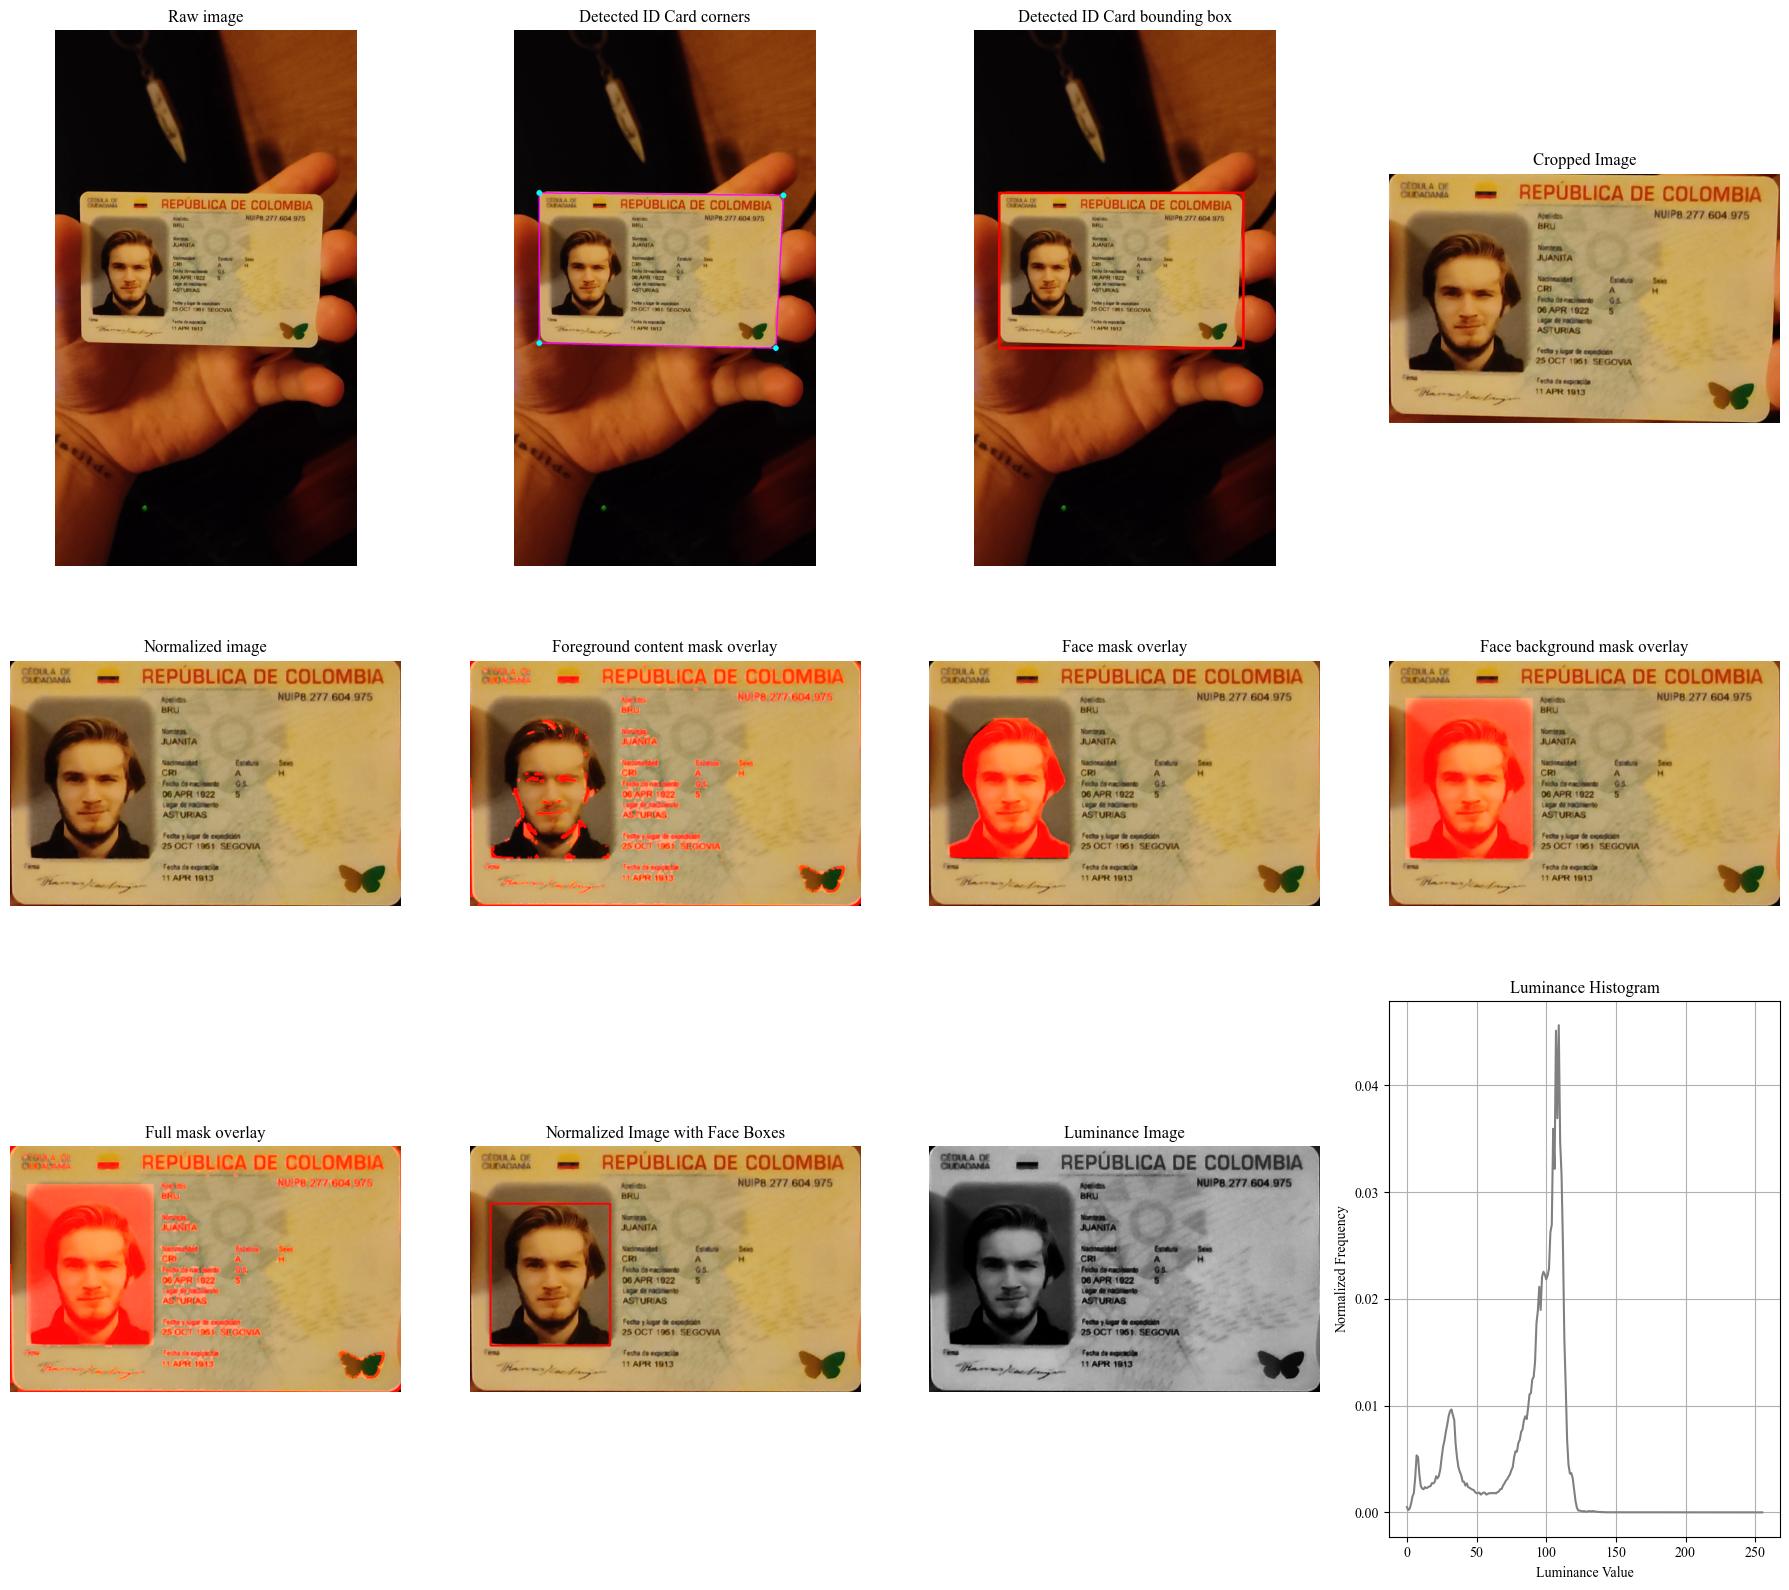

In [3]:
fig, axs = plt.subplots(3, 4, figsize=(18, 16))
axs = axs.flatten()
font_size = 12


def plot_raw_image(ax):
    print(session.get_raw_image().shape)
    ax.imshow(session.get_raw_image())
    ax.set_title("Raw image", fontsize=font_size)
    ax.axis("off")


def plot_corners(ax):
    corners = session.get_id_card_corners()
    print("Detected corners:", corners)
    img = session.get_raw_image().copy()
    for i in range(4):
        cv2.line(img, corners[i], corners[(i + 1) % 4], (255, 0, 255), 4)
    for i in range(4):
        cv2.circle(img, corners[i], 5, (0, 255, 255), 10)
    ax.imshow(img)
    ax.set_title("Detected ID Card corners", fontsize=font_size)
    ax.axis("off")


def plot_bouding_box(ax):
    corners = session.get_id_card_corners()
    x1 = min(corners[:, 0])
    y1 = min(corners[:, 1])
    x2 = max(corners[:, 0])
    y2 = max(corners[:, 1])
    box = (x1, y1, x2, y2)

    print("Detected bounding box:", box)
    img = session.get_raw_image().copy()
    
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 8)
    ax.imshow(img)
    ax.set_title("Detected ID Card bounding box", fontsize=font_size)
    ax.axis("off")


def plot_cropped_image(ax):
    cropped = session.get_cropped_image()
    ax.imshow(cropped)
    ax.set_title("Cropped Image", fontsize=font_size)
    ax.axis("off")


def plot_normalized_image(ax):
    scaled_image = session.get_normalized_image()
    print("Normalized image shape:", scaled_image.shape)
    ax.imshow(scaled_image)
    ax.set_title("Normalized image", fontsize=font_size)
    ax.axis("off")


def plot_foreground_mask_overlay(ax):
    scaled_image = session.get_normalized_image()
    foreground_mask = session.get_normalized_foreground_mask()
    stacked_mask = np.stack([foreground_mask, np.zeros(foreground_mask.shape), np.zeros(foreground_mask.shape)], axis=-1) * 255
    ax.imshow(np.clip(scaled_image + stacked_mask, 0, 255).astype(np.uint8))
    ax.set_title("Foreground content mask overlay", fontsize=font_size)
    ax.axis("off")


def plot_face_mask_overlay(ax):
    scaled_image = session.get_normalized_image()
    face_mask = session.get_normalized_face_mask()
    stacked_face_mask = np.stack([face_mask, np.zeros(face_mask.shape), np.zeros(face_mask.shape)], axis=-1) * 255
    ax.imshow(np.clip(scaled_image + stacked_face_mask, 0, 255).astype(np.uint8))
    ax.set_title("Face mask overlay", fontsize=font_size)
    ax.axis("off")


def plot_face_background_mask_overlay(ax):
    scaled_image = session.get_normalized_image()
    face_background_mask = session.get_normalized_face_background_mask()
    stacked_face_background_mask = (
        np.stack(
            [face_background_mask, np.zeros(face_background_mask.shape), np.zeros(face_background_mask.shape)], axis=-1
        )
        * 255
    )
    ax.imshow(np.clip(scaled_image + stacked_face_background_mask, 0, 255).astype(np.uint8))
    ax.set_title("Face background mask overlay", fontsize=font_size)
    ax.axis("off")


def plot_face_boxes(ax):
    scaled_image = session.get_normalized_image().copy()
    face_boxes = session.get_normalized_face_boxes()
    for box in face_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(scaled_image, (x1, y1), (x2, y2), (255, 0, 0), 4)
    ax.imshow(scaled_image, cmap="gray")
    ax.set_title("Normalized Image with Face Boxes", fontsize=font_size)
    ax.axis("off")


def plot_full_mask_overlay(ax):
    scaled_image = session.get_normalized_image()
    full_mask = session.get_normalized_face_mask()
    full_mask = np.logical_or(full_mask, session.get_normalized_face_background_mask())
    full_mask = np.logical_or(full_mask, session.get_normalized_foreground_mask())
    stacked_full_mask = np.stack([full_mask, np.zeros(full_mask.shape), np.zeros(full_mask.shape)], axis=-1) * 255
    ax.imshow(np.clip(scaled_image + stacked_full_mask, 0, 255).astype(np.uint8))
    ax.set_title("Full mask overlay", fontsize=font_size)
    ax.axis("off")



def plot_luminance_image(ax):
    luminance_image = session.get_normalized_luminance()
    ax.imshow(luminance_image, cmap="gray")
    ax.set_title("Luminance Image", fontsize=font_size)
    ax.axis("off")

def plot_luminance_histogram(ax):
    hist = session.get_normalized_luminance_histogram()
    ax.plot(range(len(hist)), hist, color='gray')
    ax.set_title("Luminance Histogram", fontsize=font_size)
    ax.set_xlabel("Luminance Value", fontsize=10)
    ax.set_ylabel("Normalized Frequency", fontsize=10)
    ax.grid(True)
    ax.axis("on")




ax_iter = iter(axs)

plot_raw_image(next(ax_iter))
plot_corners(next(ax_iter))
plot_bouding_box(next(ax_iter))
plot_cropped_image(next(ax_iter))
plot_normalized_image(next(ax_iter))
plot_foreground_mask_overlay(next(ax_iter))
plot_face_mask_overlay(next(ax_iter))
plot_face_background_mask_overlay(next(ax_iter))
plot_full_mask_overlay(next(ax_iter))
plot_face_boxes(next(ax_iter))
plot_luminance_image(next(ax_iter))
plot_luminance_histogram(next(ax_iter))

plt.tight_layout()
plt.show()

In [4]:
scores = session.get_all_scores().values()
print("\n\nComputed Scores:\n\n")
for score in scores:
    print(score)

[2026-03-09 15:18:11] [CompressionArtifacts]: Took 0.0342 seconds for 'Compression artifacts' and created keys: ['Compression artifacts']
[2026-03-09 15:18:11] [DynamicRange]: Took 0.0001 seconds for 'Dynamic range' and created keys: ['Dynamic range']
[2026-03-09 15:18:11] [IlluminationUniformity]: Calculating illumination uniformity on 66.63% of pixels.
[2026-03-09 15:18:11] [IlluminationUniformity]: Found 10/12 sections with at least 20900 (40.00%) unmasked pixels.
[2026-03-09 15:18:11] [IlluminationUniformity]: Section medians: [np.float64(105.0), np.float64(98.0), np.float64(95.0), np.float64(105.0), np.float64(96.0), np.float64(107.0), np.float64(110.0), np.float64(104.0), np.float64(98.0), np.float64(103.0)]
[2026-03-09 15:18:11] [IlluminationUniformity]: Took 0.0033 seconds for 'Illumination uniformity' and created keys: ['Illumination uniformity']
[2026-03-09 15:18:11] [LuminanceMoments]: Took 0.0001 seconds for 'Luminance mean' and created keys: ['Luminance mean', 'Luminance v

You can also create a dependency graph of all preprocessors and metrics in a session.
(This takes a few seconds to compute. Note that the result is not cached.)

In [5]:
session.verbose = False 
graph = session.dependency_graph()

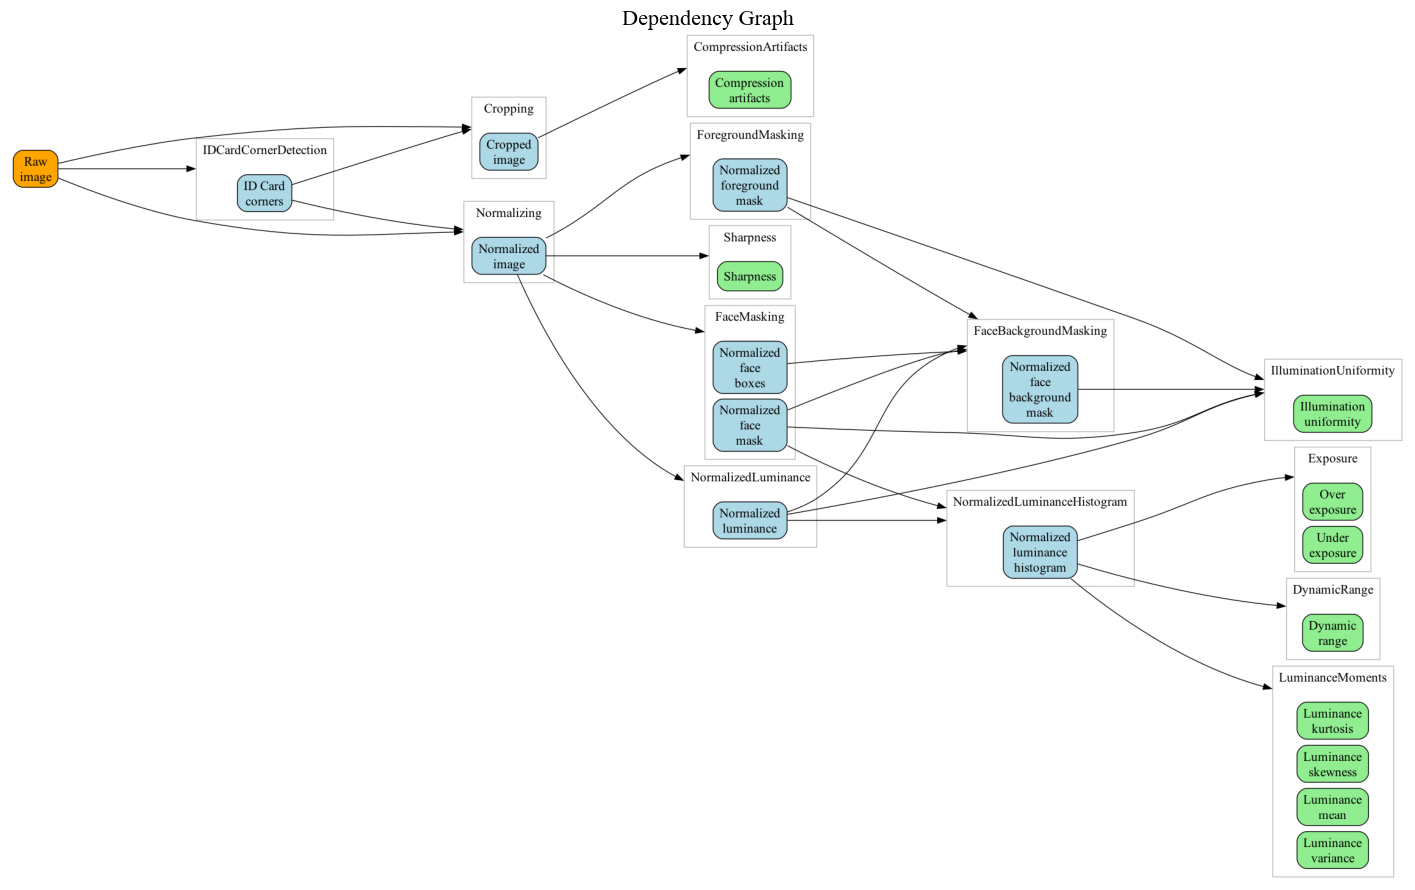

In [6]:
import tempfile
import matplotlib.image as mpimg
import pygraphviz as pgv

def sanitize_label(label: str) -> str:
    l = label.replace("score__", "").replace("_", " ").title().replace("Id Card", "ID-Card").replace("Id-card", "ID-Card")
    splits = l.split(" ")
    for i in range(1, len(splits)):
        if splits[i] not in ["ID-Card", "ID Card"]:
            splits[i] = splits[i].lower()

    l = "\n".join(splits)
    l = l.replace("ID-Card", "ID Card")
    return l

groups = {}
def iterate_all():
    for creates, prep in session.preprocessors.items():
        yield creates, prep
    for creates, metric in session.metric_creators.items():
        yield "score__" + creates, metric

for creates, pro in iterate_all():
    name = id(pro)
    if name not in groups:
        groups[name] = {
            "name": pro.__class__.__name__,
            "subgroups": []
        }
    found = False

    for subgroup in groups[name]["subgroups"]:
        if any(graph[se][0] != graph[creates][0] for se in subgroup):
            continue
        subgroup.append(creates)
        found = True
        break
    if not found:
        groups[name]["subgroups"].append([creates])

all_groups = []
for k, v in groups.items():
    for subgroup in v["subgroups"]:
        all_groups.append((v["name"], subgroup))
name_to_group = {creates: v["name"] for k, v in groups.items() for subgroup in v["subgroups"] for creates in subgroup}

A = pgv.AGraph(directed=True, strict=False, rankdir="LR", compound="true")
A.graph_attr.update(nodesep="0.1", ranksep="2.5", overlap="false", splines="true")
node_colors = {}

font_size = 16

for k, v in graph.items():
    label = sanitize_label(k)
    if k.startswith("score__"):
        node_colors[label] = "lightgreen"
    elif len(v[0]) == 0:
        node_colors[label] = "orange"
    else:
        node_colors[label] = "lightblue"
    A.add_node(
        label,
        shape="box",
        style="rounded,filled",
        fillcolor=node_colors[label],
        fontsize=font_size
    )

name_to_cluster_name = {}
cluster_anchors = {}

for idx, (group_name, subgroup) in enumerate(all_groups):
    cluster_name = f"cluster_{idx}"
    sub = A.add_subgraph(name=cluster_name, label=group_name, color="gray70", nodesep="4", ranksep="3", margin="10", pad="300", fontsize=font_size)
    anchor_name = f"{cluster_name}_anchor"
    sub.add_node(anchor_name, shape="point", width="0.01", height="0.01", label="", style="invis")
    
    cluster_anchors[cluster_name] = anchor_name
    first_node = None
    anchor_idx = len(subgroup) // 2
    for j, creates in enumerate(subgroup):
        node_name = sanitize_label(creates)
        sub.add_node(node_name, fontsize=font_size)
        name_to_cluster_name[creates] = cluster_name
        if j == anchor_idx:
            first_node = node_name
    if first_node:
        sub.add_edge(anchor_name, first_node, style="invis", weight="0", constraint="false")
    

existing_deps = set()

for k, v in graph.items():
    for dep in v[1]:
        dep_cluster = name_to_cluster_name.get(dep)
        if not dep_cluster:
            continue
        dep_anchor = cluster_anchors.get(dep_cluster)
        if dep_anchor and (k, dep_cluster) not in existing_deps:
            A.add_edge(sanitize_label(k), dep_anchor, lhead=dep_cluster, headport="w")
            existing_deps.add((k, dep_cluster))

A.layout(prog="dot")
with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
    A.draw(tmp.name)
    img = mpimg.imread(tmp.name)

plt.figure(figsize=(18, 12))
plt.imshow(img)
plt.axis("off")
plt.title("Dependency Graph", fontsize=16)
plt.show()

This graph can be used to update a value in the session. The session will delete all values that depend on the updated value, ensuring that all subsequent computations are based on the most recent data.

In [7]:
session.reset_cache()
affected_scores =  ['Dynamic range', 'Luminance variance', 'Luminance mean', 'Luminance kurtosis', 'Over exposure', 'Illumination uniformity', 'Luminance skewness', 'Under exposure']

old_scores = session.get_scores(*affected_scores)

norm_image = session.get_normalized_image()
gray_image = cv2.cvtColor(norm_image.astype(np.uint8), cv2.COLOR_RGB2GRAY)
deleted_scores, deleted_pres = session.update_preprocessed_image(PreProcessors.NORMALIZED_LUMINANCE, gray_image, graph)

new_scores = session.get_scores(*affected_scores)

for old_score, new_score in zip(old_scores, new_scores):
    print(f"Score '{old_score.name}': old value = {old_score.raw_value}, new value = {new_score.raw_value}")


Score 'Dynamic range': old value = 6.190660264914226, new value = 6.033904948302757
Score 'Luminance variance': old value = 0.014698663089563097, new value = 0.017058364563984896
Score 'Luminance mean': old value = 0.333109795782576, new value = 0.5878526692603177
Score 'Luminance kurtosis': old value = 3.086205091854437, new value = 4.722522882191006
Score 'Over exposure': old value = 0.0, new value = 0.0
Score 'Illumination uniformity': old value = 4.784349485562274, new value = 3.286335345030997
Score 'Luminance skewness': old value = 1.6260954022636467, new value = 1.9363402126412916
Score 'Under exposure': old value = 0.008376148386815715, new value = 0.00021770366177558713


# Advanced usage

## Modifying config for a metric creator

You can modify the config of a metric creator after initialization using the `update_config` method.


In [8]:
from oidiq import OIDIQSessionFactory
from oidiq.metrics.exposure import Exposure


alternative_exposure_score = Exposure(factory.config)
alternative_exposure_score.update_config(
    "under_exposure", threshold=15
)  # Note that you have to specify the metric name, as Exposure creates multiple metrics.
alternative_exposure_score.update_config(
    "over_exposure", threshold=150
)  # When your metric only creates one metric, you can omit the metric name.

factory = OIDIQSessionFactory("config.yaml")
session = factory.create_session("data/example.png")

alternate_score = alternative_exposure_score.get(
    session
)  # You could also specify metric names here to get a dictionary with just the specified metrics.
# But as the calculation function returns both metrics, it's more efficient to get them both at once.
# Important: Caching is done by the session, the metric creators and preprocessors are shared over all sessions created by the same factory. 
alternate_under = alternate_score["Under exposure"]
alternate_over = alternate_score["Over exposure"]

org_under = session.get_score("Under exposure")
org_over = session.get_score("Over exposure")
print("\n\nAlternative Exposure Scores:\n")
print(alternate_under)
print(alternate_over)

print("\n\nOriginal Exposure Scores:\n")
print(org_under)
print(org_over)



Alternative Exposure Scores:

Under exposure: 100 (0.03393) Measure of under exposure in the luminance of the normalized image.
Over exposure: 100 (0.30627) Measure of over exposure in the luminance of the normalized image.


Original Exposure Scores:

Under exposure: 100 (0.00838) Measure of under exposure in the luminance of the normalized image.
Over exposure: 100 (0.00000) Measure of over exposure in the luminance of the normalized image.


## Using modified metric creators in sessions

You can also add your modified metric directly to the session factory to allow for results caching.
But now you have to specify a new name, to not confuse the session.


In [9]:
from oidiq import OIDIQSessionFactory
from oidiq.metrics.exposure import Exposure

factory = OIDIQSessionFactory("config.yaml")
alternative_exposure_score = Exposure(factory.config)
alternative_exposure_score.update_config("under_exposure", threshold=15, name="Alternative under exposure")
alternative_exposure_score.update_config("over_exposure", threshold=150, name="Alternative over exposure")

factory.register_metric_creator(alternative_exposure_score)
session = factory.create_session("data/example.png")

alternate_score = session.get_score("Alternative under exposure")
alternate_over = session.get_score("Alternative over exposure")

org_under = session.get_score("Under exposure")
org_over = session.get_score("Over exposure")
print("\n\nAlternative Exposure Scores:\n")
print(alternate_score)
print(alternate_over)
print("\n\nOriginal Exposure Scores:\n")
print(org_under)
print(org_over)



Alternative Exposure Scores:

Alternative under exposure: 100 (0.03393) Measure of under exposure in the luminance of the normalized image.
Alternative over exposure: 100 (0.30627) Measure of over exposure in the luminance of the normalized image.


Original Exposure Scores:

Under exposure: 100 (0.00838) Measure of under exposure in the luminance of the normalized image.
Over exposure: 100 (0.00000) Measure of over exposure in the luminance of the normalized image.


## Writing your own metric creators

You can create your own metric creators using a function.

In [10]:
from oidiq import *


def example_metric_function(session: OIDIQSession, config: QualityMetricConfig):
    img = session.get_raw_image()
    return config.create_quality_metric(raw_value=img.sum(), score=42)


metric = OIDIQMetricCreator.from_function(
    func=example_metric_function,
    creates="Sum metric",
    description="The sum of all pixel values in the raw image.",
)

factory = OIDIQSessionFactory("config.yaml")
factory.register_metric_creator(metric)
session = factory.create_session("data/example.png")
session.get_score("Sum metric")

Sum metric: 42 (361260252.00000) The sum of all pixel values in the raw image.

To return mutliple metrics from a single function, you can have to specify all metric names in the `creates` parameter.

In [11]:
from oidiq import *

def example_multiple_metrics_function(session: OIDIQSession, config_mean: QualityMetricConfig, config_std: QualityMetricConfig):
    img = session.get_raw_image()
    metric_mean = config_mean.create_quality_metric(raw_value=img.mean(), score=50)
    metric_std = config_std.create_quality_metric(raw_value=img.std(), score=75)
    return metric_mean, metric_std

metric = OIDIQMetricCreator.from_function(
    func=example_multiple_metrics_function,
    creates=("Mean metric", "Std metric"),
    description=("The mean pixel value in the raw image.", "The standard deviation of pixel values in the raw image."),
)

factory = OIDIQSessionFactory("config.yaml")
factory.register_metric_creator(metric)
session = factory.create_session("data/example.png")
mean_metric = session.get_score("Mean metric")
std_metric = session.get_score("Std metric")
print(mean_metric)
print(std_metric)


Mean metric: 50 (58.07296) The mean pixel value in the raw image.
Std metric: 75 (64.97634) The standard deviation of pixel values in the raw image.


For more complex cases, you can also inherit from `OIDIQMetricCreator` directly.

In [12]:
from oidiq import *


class ExampleMetricCreator(OIDIQMetricCreator):

    # To initialize config values, you need to override init_config method and annotate it with @config
    @config("example_metric")
    def init_config(self, config: QualityMetricConfig):
        config["x"] = 10

    # To calculate the metric, you need to annotate any method with @creates
    @creates("example_metric")
    def calculate(self, session: OIDIQSession, config: QualityMetricConfig):
        img = session.get_raw_image()
        raw_value = img.sum() / config["x"] ** config["power"]
        return config.create_quality_metric(raw_value=raw_value, score=99)

    @creates("fixed_metric")
    def calculate_fixed(self, session: OIDIQSession, config: QualityMetricConfig):
        return config.create_quality_metric(raw_value=42, score=100)


session_factory = OIDIQSessionFactory("config.yaml")

example_metric_creator1 = ExampleMetricCreator(
    session_factory.config,
    overwrite_target="example_metric",
    power=2,
    name="Example metric 1",
    description="An example metric creator that divides by x squared.",
)
example_metric_creator2 = ExampleMetricCreator(
    session_factory.config,
    overwrite_target="example_metric",
    power=3,
    name="Example metric 2",
    description="An example metric creator that divides by x cubed.",
)

example_metric_creator1.update_config("example_metric", x=20)  # You can also modify config after initialization.
example_metric_creator1.update_config("fixed_metric", name="Fixed metric 1")
example_metric_creator2.update_config("fixed_metric", name="Fixed metric 2")

session_factory.register_metric_creator(example_metric_creator1)
session_factory.register_metric_creator(example_metric_creator2)

session = session_factory.create_session("data/example.png")
metric1 = session.get_score("Example metric 1")
metric2 = session.get_score("Example metric 2")
fixed_metric = session.get_score("Fixed metric 1")

print(metric1)
print(metric2)
print(fixed_metric)

Example metric 1: 99 (3612602.52000) An example metric creator that divides by x squared.
Example metric 2: 99 (361260.25200) An example metric creator that divides by x cubed.
Fixed metric 1: 100 (42.00000) 


## Creating custom preprocessors

Implementing custom preprocessors is similar to metric creators. You can create them using functions or by inheriting from `OIDIQPreprocessor`.

In [13]:
from oidiq import *

# Note that preprocessors dont nesssecarily require configs.
def example_preprocessor_function(session: OIDIQSession):
    img = session.get_raw_image()
    processed_img = img ** 2  # Simple example: square the pixel values
    return processed_img, 27

preprocessor = OIDIQPreprocessor.from_function(
    func=example_preprocessor_function,
    creates=("squared_image","27"),
)

factory = OIDIQSessionFactory("config.yaml")
factory.register_preprocessor(preprocessor)
session = factory.create_session("data/example.png")
squared_image = session.get_preprocessed_image("squared_image")
value_27 = session.get_preprocessed_image("27")

print("Squared image shape:", squared_image.shape)
print("Value 27:", value_27)

Squared image shape: (1920, 1080, 3)
Value 27: 27


You can also implement a class that inherits from `OIDIQPreprocessor` directly.

In [14]:
from oidiq import *

class ExamplePreprocessor(OIDIQPreprocessor):

    # To initialize config values, you need to override init_config method and annotate it with @config
    @config("example_config")
    def init_config(self, config):
        config["offset"] = 5

    # To calculate the preprocessed output, you need to annotate any method with @creates
    @creates("example_preprocessor")
    @config("example_config")
    def process(self, session: OIDIQSession, config):
        img = session.get_raw_image()
        processed_img = img + config["offset"]
        return processed_img
    
    # Note that you can have multiple values created by one function, while also using configs.
    @creates("constant_value", "offset*2")
    @config("example_config")
    def constant(self, session: OIDIQSession, config):
        return 100, config["offset"] * 2
    
session_factory = OIDIQSessionFactory("config.yaml")
example_preprocessor = ExamplePreprocessor(session_factory.config)
example_preprocessor.update_config("example_preprocessor", name="Example preprocessor")
example_preprocessor.update_config("constant_value", name="Constant value")
example_preprocessor.update_config("offset*2", name="Offset times two")

cur_offset = example_preprocessor.get_config()["offset"] # Note that you don't have to specify config name if there is only one 'real' config.
print("Current offset value:", cur_offset)
example_preprocessor.update_config("example_config", offset=cur_offset*3)  # You can also modify config after initialization.


session_factory.register_preprocessor(example_preprocessor)
session = session_factory.create_session("data/example.png")
preprocessed_image = session.get_preprocessed_image("Example preprocessor")
constant_value = session.get_preprocessed_image("Constant value")
offset_times_two = session.get_preprocessed_image("Offset times two")

print("Preprocessed image shape:", preprocessed_image.shape)
print("Constant value:", constant_value)
print("Offset times two:", offset_times_two)


Current offset value: 5
Preprocessed image shape: (1920, 1080, 3)
Constant value: 100
Offset times two: 10


# Batch processing

Everything that works for single image sessions also works for batch sessions. You can create a batch session using the `create_batch_session` method of the session factory.

In [15]:
from oidiq import *
session_factory = OIDIQSessionFactory("config.yaml")
session = session_factory.create_batch_session(
"data/example.png",
"tests/data/black_white.png",
"tests/data/red.png",
"tests/data/test_id.png",
"tests/data/white.png"
)
batch_scores = session.get_all_scores()
for key, score in batch_scores.items():
    print(f"Scores for '{key}':")
    for s in score:
        print("\t", s)

Scores for 'Compression artifacts':
	 Compression artifacts: 83 (0.90810) Level of compression artifacts in the normalized image.
	 Compression artifacts: 92 (0.95411) Level of compression artifacts in the normalized image.
	 Compression artifacts: 0 (0.00000) Level of compression artifacts in the normalized image.
	 Compression artifacts: 97 (0.93325) Level of compression artifacts in the normalized image.
	 Compression artifacts: 0 (0.00000) Level of compression artifacts in the normalized image.
Scores for 'Dynamic range':
	 Dynamic range: 77 (6.19066) Dynamic range of the luminance distribution in the normalized image.
	 Dynamic range: 13 (1.01447) Dynamic range of the luminance distribution in the normalized image.
	 Dynamic range: 0 (0.00000) Dynamic range of the luminance distribution in the normalized image.
	 Dynamic range: 82 (6.54092) Dynamic range of the luminance distribution in the normalized image.
	 Dynamic range: 0 (0.00000) Dynamic range of the luminance distribution 

To create custom preprocessors or metric creators for batch sessions, one option is to set the `batch_size` parameter when creating them using functions.

In [16]:
from oidiq import *

def batch_mean_metric_function(session: OIDIQBatchSession, config: QualityMetricConfig):
    img = session.get_raw_image()
    print("Batch raw image shapes:", [i.shape for i in img])
    return [config.create_quality_metric(raw_value=img[i].mean(), score=i) for i in range(len(img))]

batch_metric = OIDIQMetricCreator.from_function(
    func=batch_mean_metric_function,
    creates="Mean pixel value metric",
    batch_size=2,
)
factory = OIDIQSessionFactory("config.yaml")
factory.register_metric_creator(batch_metric)
session = factory.create_batch_session(
    "data/example.png",
    "tests/data/black_white.png",
    "tests/data/red.png",
)
mean_metrics = session.get_score("Mean pixel value metric")
for i, metric in enumerate(mean_metrics):
    print(f"Image {i} mean pixel value metric: {metric}")

Batch raw image shapes: [(1920, 1080, 3), (896, 1134, 3)]
Batch raw image shapes: [(3, 3, 3)]
Image 0 mean pixel value metric: Mean pixel value metric: 0 (58.07296) 
Image 1 mean pixel value metric: Mean pixel value metric: 1 (132.41547) 
Image 2 mean pixel value metric: Mean pixel value metric: 0 (85.00000) 


Or you can implement a class that inherits from `OIDIQPreprocessor` or `OIDIQMetricCreator` directly.

When implementing your own batch preprocessors or metric creators, make sure that the functions return lists of results, one for each image in the batch.

In [17]:
from oidiq import *
class StdPreprocessor(OIDIQPreprocessor):

    @creates("std")
    @batching(4)
    @config()
    def process(self, session: OIDIQBatchSession):
        img = session.get_raw_image()
        print("Batch raw image shapes:", [i.shape for i in img])
        return [np.std(i) for i in img]
factory = OIDIQSessionFactory("config.yaml")
std_preprocessor = StdPreprocessor(factory.config)

std_preprocessor.update_config(batch_size=1)  # You can also set batch size via config. The config value will override the one set during initialization.

factory.register_preprocessor(std_preprocessor)
session = factory.create_batch_session(
    "data/example.png",
    "tests/data/black_white.png",
)
std_values = session.get_preprocessed_image("std")
for i, std in enumerate(std_values):
    print(f"Image {i} standard deviation: {std}")

Batch raw image shapes: [(1920, 1080, 3)]
Batch raw image shapes: [(896, 1134, 3)]
Image 0 standard deviation: 64.97633705904452
Image 1 standard deviation: 127.40521251147928


Batch sessions can be accessed like lists of single sessions. 

In [18]:
from oidiq import *

session_factory = OIDIQSessionFactory("config.yaml")
session = session_factory.create_batch_session(
    "data/example.png",
    "tests/data/black_white.png",
    "tests/data/red.png",
)

for s in session: 
    print("Luminance mean score:", s.get_score("Luminance mean"))

for s in session[:2]:
    print("Over exposure score (first two images):", s.get_score("Over exposure"))


Luminance mean score: Luminance mean: 94 (0.33311) Mean of the normalized luminance values.
Luminance mean score: Luminance mean: 100 (0.51960) Mean of the normalized luminance values.
Luminance mean score: Luminance mean: 56 (0.21176) Mean of the normalized luminance values.
Over exposure score (first two images): Over exposure: 100 (0.00000) Measure of over exposure in the luminance of the normalized image.
Over exposure score (first two images): Over exposure: 100 (0.51931) Measure of over exposure in the luminance of the normalized image.
